In [1]:
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

import scanpy as sc
#ctrl1_data only contains the all the tubule annotations:
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")
ctrl1_data.obs.shape

# read the corresponding image:
from PIL import Image
Image.MAX_IMAGE_PIXELS = 1_000_000_000
img = Image.open("data/2um/Ctrl_1A2/Ctrl_1A2.tif")

#Subset the AnnData to only contain proximal tubules
ctrl1_A2_PT=ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()]
ctrl1_A2_PT.shape #to check the dimensions of the subset matrix.
ctrl1_A2_PT.obs.head()

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929


In [ ]:
# read the corresponding image:
from PIL import Image
Image.MAX_IMAGE_PIXELS = 1_000_000_000
img = Image.open("data/2um/Ctrl_1A2/Ctrl_1A2.tif")

In [2]:
#Importing the geojson files which contains the proximal tubule annotations and boudary information.
import geopandas as gpd
gdf=gpd.read_file("data/2um/geojson/Ctrl_1A2_tubules_processed_caleb.geojson")
gdf.head()
gdf.shape

#Remove invlid geojsons:
gdf = gdf[gdf.geometry.notna()]
gdf = gdf[~gdf.geometry.is_empty]
gdf = gdf[gdf.is_valid]
gdf.shape

(11644, 6)

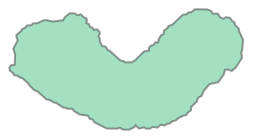

In [5]:
#Sanity Check
tubule=gdf[gdf["id"]=="929"]
geom=tubule.geometry.iloc[0]
geom

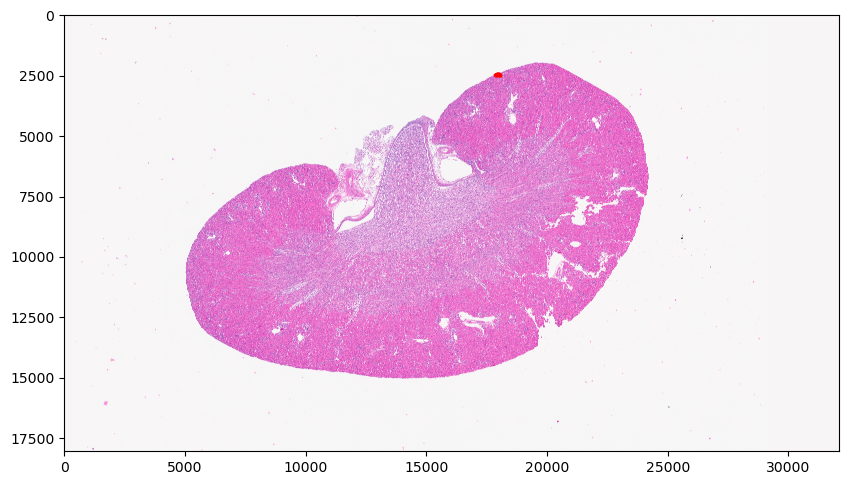

In [6]:
# Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))

# Show image
ax.imshow(img)

# Overlay boundary
x, y = geom.exterior.xy
ax.plot(x, y, color='red', linewidth=2)

# IMPORTANT: flip y-axis to match image coordinates
ax.set_ylim(img.size[1], 0)

plt.show()

In [9]:
from shapely.geometry import Polygon, MultiPolygon

def plot_tubule_patch(gdf, img, tubule_id="929", buffer=200):
    # Get geometry
    tubule = gdf[gdf["id"] == str(tubule_id)]
    if tubule.empty:
        raise ValueError(f"Tubule {tubule_id} not found")
    
    geom = tubule.geometry.iloc[0]

    # Bounding box (minx, miny, maxx, maxy)
    minx, miny, maxx, maxy = geom.bounds

    # Add buffer
    minx -= buffer
    miny -= buffer
    maxx += buffer
    maxy += buffer

    # Clamp to image bounds
    width, height = img.size
    minx = max(0, int(minx))
    miny = max(0, int(miny))
    maxx = min(width, int(maxx))
    maxy = min(height, int(maxy))

    # Crop image
    crop = img.crop((minx, miny, maxx, maxy))

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(crop)

    # Helper to plot polygon(s)
    def plot_geom(g):
        if isinstance(g, Polygon):
            x, y = g.exterior.xy
            # shift coords into cropped frame
            x = [xi - minx for xi in x]
            y = [yi - miny for yi in y]
            ax.plot(x, y, color='red', linewidth=2)
        elif isinstance(g, MultiPolygon):
            for poly in g.geoms:
                plot_geom(poly)

    plot_geom(geom)

    # Flip y-axis to match image coordinates
    ax.set_ylim(crop.size[1], 0)

    ax.set_title(f"Tubule {tubule_id}")
    plt.show()

    #return crop

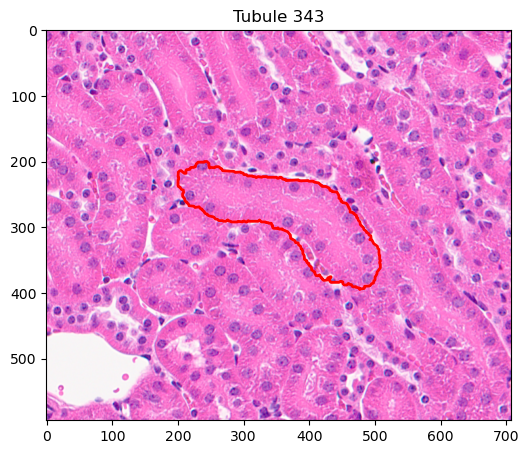

In [11]:
plot_tubule_patch(gdf, img, tubule_id="343", buffer=200)